In [1]:
#Plots and data for Experiment 2 in the paper
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF as NMF_sklearn
from nmf import NMF as NMF_potts
import copy
from scipy import stats

## Dirac-3 experiment 2
### For test set A

In [2]:
#Important functions to get the median results
#Since the original results didn't decode the median of the dirac-3 runs, we need to process that over here

#Sometimes, we get multiple counts of the same solution, E.g for 3 runs for a problem that consists of 3 variables, we may get
#counts = [2,1] soln = [[0.4,0.3,0.1], [0.6,0.0,0.1]] (assuming energies are ordered in an ascending manner),
# we need the solutions to be reformatted so that each count is 1,
#i.e new_soln = [[0.4,0.3,0.1],[0.6,0.0,0.1],[0.6,0.0,0.1]]
def get_expanded_result(counts,energies,soln):

    new_counts = []
    new_energies = []
    new_soln = []
    for i in range(len(counts)):
        for _ in range(counts[i]):
            new_counts.append(1)
            new_energies.append(energies[i])
            new_soln.append(soln[i])
    return new_counts, new_energies, new_soln

#Function that picks solution (and related info) that is closest to the median of all the runs
def get_closest2median(energies,soln):    
    median_energy = np.median(energies)
    closest_idx = np.argmin(np.abs(energies - median_energy))
    closest_energy = energies[closest_idx]
    closest_soln = copy.deepcopy(soln[closest_idx])
    return median_energy,closest_energy,closest_soln

#using a solution, get absolute and relative errors (along with V,W)
def get_errors(V,soln,n,k,m,var_dict):
    #First get W and H matrices
    #Get W
    W = np.zeros((n,k))
    H = np.zeros((k,m))
    V_rec = np.zeros((n,m))
    for i in range(n):
        for j in range(k):
                tempwstr = 'w_'+str(i)+","+str(j)
                W[i,j] = soln[var_dict[tempwstr]-1]

        #Get H
        for i in range(k):
            for j in range(m):
                temphstr = 'h_'+str(i)+","+str(j)
                H[i,j] = soln[var_dict[temphstr]-1]

        #Get V_rec
        V_rec = W @ H
    
    abs_error = np.linalg.norm(V - V_rec)
    rel_error = abs_error/np.linalg.norm(V)
    
    return abs_error,rel_error, W, H #W and H are new 2a

In [3]:
#Dimentions, note what we call p in the paper is called k in the code
n = 4
k = 3
m = 8
resfolder = 'results' #alt being True will compute results for tol = e-15
hist_data1 = [] #will hold data for schedule 1 (will go into histogram)
hist_data2 = [] #will hold data for schedule 2 (will go into histogram)
hist_data3 = [] #will hold data for third diagram (diff between sched1 and sched2 pott error)


In [4]:
#Get the counts for cases where Scikit or Fusion was better than the other (for a particular relaxation schedule)
relaxation_schedule = 2
false_ctr = 0
true_ctr = 0
equal_ctr = 0
hist_data1 = []
time_dict = {}
time_dict[1] = []
time_dict[2] = []
for i in range(0,100):
    res_filename = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
    res_filepath = "./test_matrices/dirac3_exp2/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename 
    f = np.load(res_filepath)
    diracfile = dict(f)
    f.close()

    #Setting up the problem to get var_dict (to get W and H and rel_error for median answers)
    filename = 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+".npy"
    filepath = "./test_matrices/dirac3_exp2/size_" + str(n) + "x" + str(m) + "/" + filename 
    V = np.load(filepath)

    #Now for dirac-3
    V = V.astype(float)
    size = (n*k) + (k*m)
    nmf1 = NMF_potts(V,k,size)
    nmf1.encode_problem()

    #Get median solution
    #Get the unrolled soln and energies - to calculate median
    #Here, energies are already sorted (ascending)
    _, energies, soln = get_expanded_result(diracfile['counts'],diracfile['energies'],diracfile['solutions'])
    
    median_energy,closest_energy,closest_soln = get_closest2median(energies,soln)

    abs_error_dirac3,rel_error_dirac3,W_dirac3,H_dirac3 = get_errors(V,closest_soln,n,k,m,nmf1.var_dict)

    #Fusion
    model = NMF_sklearn(n_components=k,init='custom')
    W_fusion = model.fit_transform(V,W=W_dirac3,H=H_dirac3)
    H_fusion = model.components_
    V_rec_fusion = W_fusion @ H_fusion

    
    abs_error_fusion = np.linalg.norm(V-V_rec_fusion)
    rel_error_fusion = abs_error_fusion/np.linalg.norm(V)
    
    if rel_error_fusion < diracfile['rel_error_sklearn']:
        true_ctr += 1
    elif rel_error_fusion > diracfile['rel_error_sklearn']:
        false_ctr += 1
    else:
        equal_ctr += 1
    if diracfile['rel_error_potts'] >= rel_error_dirac3:
        print("EEEYyYYY")
print("Times where fusion was better:",true_ctr)
print("Times where plain sklearn was better:",false_ctr)
print("Where equal",equal_ctr)

c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warni

Times where fusion was better: 77
Times where plain sklearn was better: 23
Where equal 0


c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warni

In [5]:
#Get information about the percentage decrease in relative errors for the two schedules

f1_better_ctr = 0
f2_better_ctr = 0
#time_dict = {} #I just want the times
#time_dict[1] = [] #For sched 1
#time_dict[2] = [] #For sched 2
for i in range(100):

    res_filename1 = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(1)+".npz"
    res_filepath1 = "./test_matrices/dirac3_exp2/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename1
    res_filename2 = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(2)+".npz"
    res_filepath2 = "./test_matrices/dirac3_exp2/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename2 
    f1 = np.load(res_filepath1)
    f2 = np.load(res_filepath2)

    #Get timings
    time_dict[1].append(0.1*float(f1['device_usage_s']))
    time_dict[2].append(0.1*float(f2['device_usage_s']))


    #Setting up the problem to get var_dict (to get W and H and rel_error for median answers)
    filename = 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+".npy"
    filepath = "./test_matrices/dirac3_exp2/size_" + str(n) + "x" + str(m) + "/" + filename 
    V = np.load(filepath)

    #Now for dirac-3
    V = V.astype(float)
    size = (n*k) + (k*m)
    nmf1 = NMF_potts(V,k,size)
    nmf1.encode_problem()

    #Get median solution
    #Get the unrolled soln and energies - to calculate median
    #For f1
    _, energies1, soln1 = get_expanded_result(f1['counts'],f1['energies'],f1['solutions'])
    median_energy1,closest_energy1,closest_soln1 = get_closest2median(energies1,soln1)

    abs_error_dirac31,rel_error_dirac31,W_dirac31,H_dirac31 = get_errors(V,closest_soln1,n,k,m,nmf1.var_dict)

    #For f2
    _, energies2, soln2 = get_expanded_result(f2['counts'],f2['energies'],f2['solutions'])
    median_energy2,closest_energy2,closest_soln2 = get_closest2median(energies2,soln2)

    abs_error_dirac32,rel_error_dirac32,W_dirac32,H_dirac32 = get_errors(V,closest_soln2,n,k,m,nmf1.var_dict)

    #Fusion f1
    model1 = NMF_sklearn(n_components=k,init='custom')
    W_fusion1 = model.fit_transform(V,W=W_dirac31,H=H_dirac31)
    H_fusion1 = model.components_
    V_rec_fusion1 = W_fusion1 @ H_fusion1

    abs_error_fusion1 = np.linalg.norm(V-V_rec_fusion1)
    rel_error_fusion1 = abs_error_fusion1/np.linalg.norm(V)

    #Fusion f2
    model2 = NMF_sklearn(n_components=k,init='custom')
    W_fusion2 = model.fit_transform(V,W=W_dirac32,H=H_dirac32)
    H_fusion2 = model.components_
    V_rec_fusion2 = W_fusion2 @ H_fusion2

    abs_error_fusion2 = np.linalg.norm(V-V_rec_fusion2)
    rel_error_fusion2 = abs_error_fusion2/np.linalg.norm(V)

    hist_data1.append( (f1['rel_error_sklearn'] - rel_error_fusion1)*100/f1['rel_error_sklearn'])
    hist_data2.append( (f2['rel_error_sklearn'] - rel_error_fusion2)*100/f2['rel_error_sklearn'])

    hist_data3.append((rel_error_dirac31 - rel_error_dirac32)*100/rel_error_dirac32)
    if rel_error_fusion1 > rel_error_fusion2:
        f2_better_ctr += 1
    elif rel_error_fusion1 < rel_error_fusion2:
        f1_better_ctr += 1
    f1.close()
    f2.close()

c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warni

In [6]:
#Minor comparison between relaxation schedule 1 and 2, not in the paper
print("time sched 1 was better:",f1_better_ctr)
print("time sched 2 was better:",f2_better_ctr)

time sched 1 was better: 50
time sched 2 was better: 50


In [7]:
print("Best improvement over sklearn (sched 1):",round(np.array(hist_data1).max(),4),"%")
print("Worst decline over sklearn (sched 1):",round(np.array(hist_data1).min(),4),"%")
print("Median value (sched 1):",round(np.median(hist_data1),5),"%")
print("MAD value (sched 1):",round(stats.median_abs_deviation(hist_data1),4))
print("Best improvement over sklearn (sched 2):",round(np.array(hist_data2).max(),4),"%")
print("Worst decline over sklearn (sched 2):",round(np.array(hist_data2).min(),4),"%")
print("Median value (sched 2):",round(np.median(hist_data2),5),"%")
print("MAD value (sched 2):",round(stats.median_abs_deviation(hist_data2),4))


Best improvement over sklearn (sched 1): 11.5768 %
Worst decline over sklearn (sched 1): -9.2894 %
Median value (sched 1): 3e-05 %
MAD value (sched 1): 0.0001
Best improvement over sklearn (sched 2): 11.5768 %
Worst decline over sklearn (sched 2): -9.7023 %
Median value (sched 2): 4e-05 %
MAD value (sched 2): 0.0001


In [8]:
#What if you only kept the hist data that was positive
hist_data1 = np.array(hist_data1)
hist_data1 = hist_data1[hist_data1 >= 0]
hist_data2 = np.array(hist_data2)
hist_data2 = hist_data2[hist_data2 >= 0]


In [9]:
#If i only want the median improvement
#It will only take the positive cases, therefore we term it median improvement rather than median value
print("Median improvement value (sched 1):",round(np.median(hist_data1),4),"%")
print("MAD improvement value (sched 1):",round(stats.median_abs_deviation(hist_data1),4))
print("Median improvement value (sched 2):",round(np.median(hist_data2),4),"%")
print("MAD improvement value (sched 2):",round(stats.median_abs_deviation(hist_data2),4))

Median improvement value (sched 1): 0.0001 %
MAD improvement value (sched 1): 0.0001
Median improvement value (sched 2): 0.0001 %
MAD improvement value (sched 2): 0.0001


C:\Users\User\AppData\Local\Temp\ipykernel_19408\756684928.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(0,120)
C:\Users\User\AppData\Local\Temp\ipykernel_19408\756684928.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(0,120)


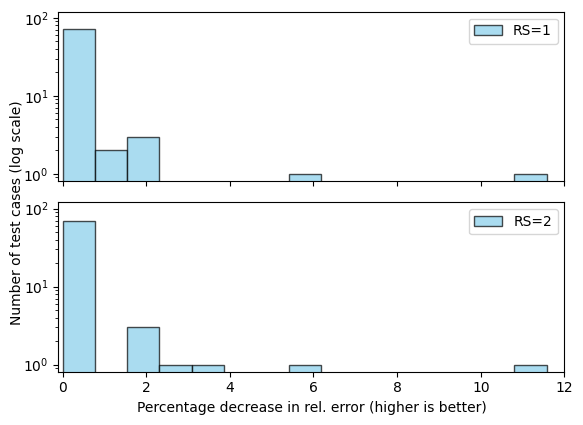

In [10]:
#Finally let us plot the histogram
fig, ax = plt.subplots(2,1,sharey=True, sharex=True, tight_layout=True)


ax[0].hist(hist_data1,bins=15,label="RS=1",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[1].hist(hist_data2,bins=15,label="RS=2",color='skyblue', edgecolor='black', alpha=0.7,density=False)

fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)
fig.text(0.015, 0.5, 'Number of test cases (log scale)', ha='center', va='center', rotation='vertical')
ax[0].legend()
ax[1].legend()

ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_xlim(-0.1,12)
ax[1].set_xlim(-0.1,12)

ax[0].set_ylim(0,120)
ax[1].set_ylim(0,120)

ax[1].set_xlabel('Percentage decrease in rel. error (higher is better)')

plt.savefig("plot_exp2_setA.pdf")

plt.show()

In [11]:
#Tertiary data
print("Length of hist_data1 samples that are postive:",len(hist_data1))
print("Length of hist_data2 samples that are postive:",len(hist_data2))

Length of hist_data1 samples that are postive: 78
Length of hist_data2 samples that are postive: 77


Text(0, 0.5, 'Number of test cases')

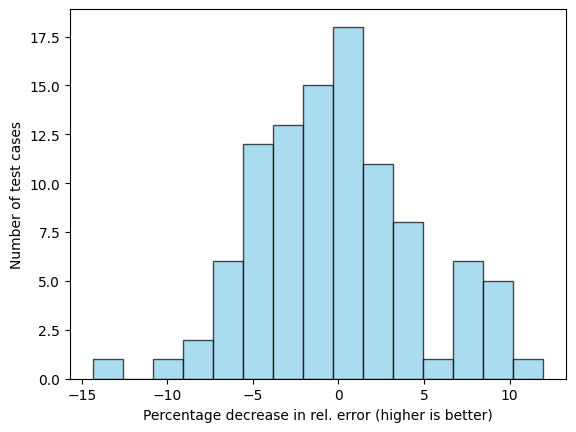

In [12]:
#Figure for comparing sched 1 and sched 2 (not in the paper)
fig, ax = plt.subplots()
ax.hist(hist_data3,bins=15,color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel("Percentage decrease in rel. error (higher is better)")
ax.set_ylabel("Number of test cases")

In [13]:
#Median time for solving problems (as decided by the Dirac-3 machine)
print("Median time for sched 1:",np.median(time_dict[1]))
print("Median time for sched 2:",np.median(time_dict[2]))

Median time for sched 1: 6.4
Median time for sched 2: 12.9


### Same routine as above but for test set B

In [14]:
n = 4
k = 3
m = 8
resfolder = 'results' 
hist_data1 = [] #will hold data for schedule 1 (will go into histogram)
hist_data2 = [] #will hold data for schedule 2 (will go into histogram)
hist_data3 = [] #will hold data for third diagram (diff between sched1 and sched2 pott error)


In [15]:
#Get the counts for cases where Scikit or Fusion was better than the other (for a particular relaxation schedule)
relaxation_schedule = 2
false_ctr = 0
true_ctr = 0
equal_ctr = 0
hist_data1 = []

for i in range(0,100):
    res_filename = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(relaxation_schedule)+".npz"
    res_filepath = "./test_matrices/dirac3_exp2a/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename 
    f = np.load(res_filepath)
    diracfile = dict(f)
    f.close()

    #Setting up the problem to get var_dict (to get W and H and rel_error for median answers)
    filename = 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+".npz"
    filepath = "./test_matrices/dirac3_exp2a/size_" + str(n) + "x" + str(m) + "/" + filename 
    f = np.load(filepath)
    V = f['V']
    f.close()

    #Now for dirac-3
    V = V.astype(float)
    size = (n*k) + (k*m)
    nmf1 = NMF_potts(V,k,size)
    nmf1.encode_problem()

    #Get median solution
    #Get the unrolled soln and energies - to calculate median
    _, energies, soln = get_expanded_result(diracfile['counts'],diracfile['energies'],diracfile['solutions'])
    median_energy,closest_energy,closest_soln = get_closest2median(energies,soln)

    abs_error_dirac3,rel_error_dirac3,W_dirac3,H_dirac3 = get_errors(V,closest_soln,n,k,m,nmf1.var_dict)

    #Fusion
    model = NMF_sklearn(n_components=k,init='custom')
    W_fusion = model.fit_transform(V,W=W_dirac3,H=H_dirac3)
    H_fusion = model.components_
    V_rec_fusion = W_fusion @ H_fusion

    
    abs_error_fusion = np.linalg.norm(V-V_rec_fusion)
    rel_error_fusion = abs_error_fusion/np.linalg.norm(V)
    
    if rel_error_fusion < diracfile['rel_error_sklearn']:
        true_ctr += 1
    elif rel_error_fusion > diracfile['rel_error_sklearn']:
        false_ctr += 1
    else:
        equal_ctr += 1
    if diracfile['rel_error_potts'] >= rel_error_dirac3:
        print("EEEYyYYY")
print("Times where fusion was better:",true_ctr)
print("Times where plain sklearn was better:",false_ctr)
print("Where equal",equal_ctr)

c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warni

Times where fusion was better: 90
Times where plain sklearn was better: 10
Where equal 0


In [16]:

#Get information about the percentage decrease in relative errors for the two schedules

f1_better_ctr = 0
f2_better_ctr = 0
for i in range(100):

    res_filename1 = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(1)+".npz"
    res_filepath1 = "./test_matrices/dirac3_exp2a/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename1
    res_filename2 = 'res_' + 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+"_sched_"+str(2)+".npz"
    res_filepath2 = "./test_matrices/dirac3_exp2a/size_" + str(n) + "x" + str(m) + "/"+resfolder+"/" + res_filename2 
    f1 = np.load(res_filepath1)
    f2 = np.load(res_filepath2)

    #Get timings
    time_dict[1].append(0.1*float(f1['device_usage_s']))
    time_dict[2].append(0.1*float(f2['device_usage_s']))


    #Setting up the problem to get var_dict (to get W and H and rel_error for median answers)
    filename = 'mat_'+str(n)+'x'+str(m)+"_"+str(i)+".npz"
    filepath = "./test_matrices/dirac3_exp2a/size_" + str(n) + "x" + str(m) + "/" + filename 
    f = np.load(filepath)
    V = f['V']
    f.close()

    #Now for dirac-3
    V = V.astype(float)
    size = (n*k) + (k*m)
    nmf1 = NMF_potts(V,k,size)
    nmf1.encode_problem()

    #Get median solution
    #Get the unrolled soln and energies - to calculate median
    #For f1
    _, energies1, soln1 = get_expanded_result(f1['counts'],f1['energies'],f1['solutions'])
    median_energy1,closest_energy1,closest_soln1 = get_closest2median(energies1,soln1)

    abs_error_dirac31,rel_error_dirac31,W_dirac31,H_dirac31 = get_errors(V,closest_soln1,n,k,m,nmf1.var_dict)

    #For f2
    _, energies2, soln2 = get_expanded_result(f2['counts'],f2['energies'],f2['solutions'])
    median_energy2,closest_energy2,closest_soln2 = get_closest2median(energies2,soln2)

    abs_error_dirac32,rel_error_dirac32,W_dirac32,H_dirac32 = get_errors(V,closest_soln2,n,k,m,nmf1.var_dict)

    #Fusion f1
    model1 = NMF_sklearn(n_components=k,init='custom')
    W_fusion1 = model.fit_transform(V,W=W_dirac31,H=H_dirac31)
    H_fusion1 = model.components_
    V_rec_fusion1 = W_fusion1 @ H_fusion1

    abs_error_fusion1 = np.linalg.norm(V-V_rec_fusion1)
    rel_error_fusion1 = abs_error_fusion1/np.linalg.norm(V)

    #Fusion f2
    model2 = NMF_sklearn(n_components=k,init='custom')
    W_fusion2 = model.fit_transform(V,W=W_dirac32,H=H_dirac32)
    H_fusion2 = model.components_
    V_rec_fusion2 = W_fusion2 @ H_fusion2

    abs_error_fusion2 = np.linalg.norm(V-V_rec_fusion2)
    rel_error_fusion2 = abs_error_fusion2/np.linalg.norm(V)

    hist_data1.append( (f1['rel_error_sklearn'] - rel_error_fusion1)*100/f1['rel_error_sklearn'])
    hist_data2.append( (f2['rel_error_sklearn'] - rel_error_fusion2)*100/f2['rel_error_sklearn'])

    hist_data3.append((rel_error_dirac31 - rel_error_dirac32)*100/rel_error_dirac32)
    if rel_error_fusion1 > rel_error_fusion2:
        f2_better_ctr += 1
    elif rel_error_fusion1 < rel_error_fusion2:
        f1_better_ctr += 1
    f1.close()
    f2.close()

c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\User\Envs\research_2023\Lib\site-packages\sklearn\decomposition\_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warni

In [17]:
#Comparing fusion results for both schedules (against each other)
print("time sched 1 was better:",f1_better_ctr)
print("time sched 2 was better:",f2_better_ctr)

time sched 1 was better: 39
time sched 2 was better: 61


In [18]:
#Numbers
print("Best improvement over sklearn (sched 1):",round(np.array(hist_data1).max(),4),"%")
print("Worst decline over sklearn (sched 1):",round(np.array(hist_data1).min(),4),"%")
print("Median value (sched 1):",round(np.median(hist_data1),4),"%")
print("MAD value (sched 1):",round(stats.median_abs_deviation(hist_data1),4))
print("Best improvement over sklearn (sched 2):",round(np.array(hist_data2).max(),4),"%")
print("Worst decline over sklearn (sched 2):",round(np.array(hist_data2).min(),4),"%")
print("Median value (sched 2):",round(np.median(hist_data2),4),"%")
print("MAD value (sched 2):",round(stats.median_abs_deviation(hist_data2),4))

Best improvement over sklearn (sched 1): 99.8797 %
Worst decline over sklearn (sched 1): -2806.4505 %
Median value (sched 1): 61.3189 %
MAD value (sched 1): 26.8686
Best improvement over sklearn (sched 2): 99.5046 %
Worst decline over sklearn (sched 2): -607.4047 %
Median value (sched 2): 70.8595 %
MAD value (sched 2): 17.1538


In [19]:
#What if you only kept the hist data that was positive
hist_data1 = np.array(hist_data1)
hist_data1 = hist_data1[hist_data1 >= 0]
hist_data2 = np.array(hist_data2)
hist_data2 = hist_data2[hist_data2 >= 0]

In [20]:
#If i only want the median improvement
#I will only take the positive cases
print("Median improvement value (sched 1):",round(np.median(hist_data1),4),"%")
print("MAD improvement value (sched 1):",round(stats.median_abs_deviation(hist_data1),4))
print("Median improvement value (sched 2):",round(np.median(hist_data2),4),"%")
print("MAD improvement value (sched 2):",round(stats.median_abs_deviation(hist_data2),4))

Median improvement value (sched 1): 70.3181 %
MAD improvement value (sched 1): 14.8157
Median improvement value (sched 2): 75.1576 %
MAD improvement value (sched 2): 12.7089


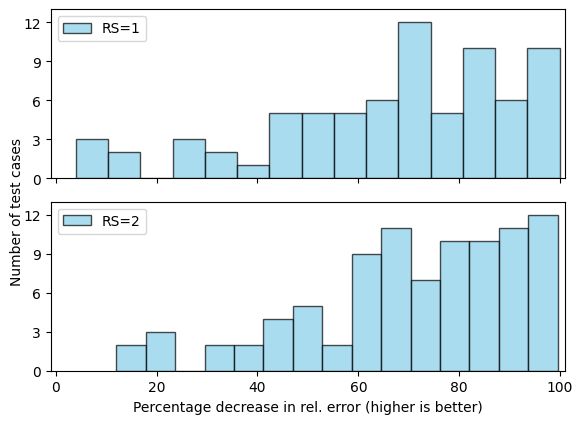

In [ ]:
#Histograms for the test set B
fig, ax = plt.subplots(2,1,sharey=True, sharex=True, tight_layout=True)


ax[0].hist(hist_data1,bins=15,label="RS=1",color='skyblue', edgecolor='black', alpha=0.7,density=False)
ax[1].hist(hist_data2,bins=15,label="RS=2",color='skyblue', edgecolor='black', alpha=0.7,density=False)

fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)
fig.text(0.015, 0.5, 'Number of test cases', ha='center', va='center', rotation='vertical')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')

#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax[0].set_xlim(-1,101)
ax[1].set_xlim(-1,101)

ax[0].set_ylim(0,13)
ax[1].set_ylim(0,13)

ax[0].set_yticks(np.arange(0,13,3))
ax[1].set_yticks(np.arange(0,13,3))

ax[1].set_xlabel('Percentage decrease in rel. error (higher is better)')
plt.savefig('plot_exp2_setB.pdf')
plt.show()

Text(0, 0.5, 'Number of test cases')

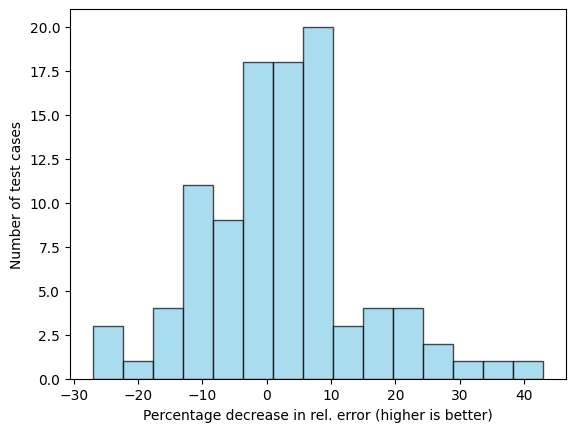

In [ ]:
#Figure for comparing sched 1 and sched 2 dirac-3 (not in the paper)
fig, ax = plt.subplots()
ax.hist(hist_data3,bins=15,color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel("Percentage decrease in rel. error (higher is better)")
ax.set_ylabel("Number of test cases")

In [23]:
print("Median time for sched 1:",np.median(time_dict[1]))
print("Median time for sched 2:",np.median(time_dict[2]))

Median time for sched 1: 6.5
Median time for sched 2: 13.0


In [24]:
#P-value calculation
from math import comb
def p_val(nb,nw):
    agg_p = 0 #aggregator
    for k in range(nb, nb+nw+1):
        agg_p += comb(nb+nw,k) #<--- I think this is the correction version
    agg_p *= (1/2)**(nb+nw)

    return agg_p

In [ ]:
#Calculating the p values
print("75 better:",p_val(75,25) )
print("90 better:",p_val(90,10) )
print("78 better:",p_val(78,22) )
print("77 better:",p_val(77,23) )

75 better: 2.818141017102701e-07
90 better: 1.5316450877189926e-17
78 better: 7.95266423689307e-09
77 better: 2.7567903879250267e-08


In [26]:
100-77

23